In [14]:
# Vérifie la taille des batches de validation
for batch, labels in ds.val.take(1):
    print(f"Batch size val  : {batch['hrtf'].shape[0]}")
    print(f"Shape ear_left  : {batch['ear_left'].shape}")
    print(f"Shape hrtf      : {batch['hrtf'].shape}")


Batch size val  : 8
Shape ear_left  : (8, 224, 224, 3)
Shape hrtf      : (8, 121, 129, 2)


In [ ]:
import sys, os
from pathlib import Path

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)


In [ ]:
import importlib
import src.models.trainer
importlib.reload(src.models.trainer)

from src.models.trainer import Trainer

In [ ]:
import tensorflow as tf
from src.models import EarEncoder, HRTFEncoder, ContrastiveModel, Trainer
from src.multimodal import MultimodalDataset

ds       = MultimodalDataset.load('dataset/preprocessed_dataset.npz', batch_size=8)
enc_ear  = EarEncoder(embedding_dim=128)
enc_hrtf = HRTFEncoder(n_sh=121, n_freqs=129, embedding_dim=128)
model    = ContrastiveModel(enc_ear, enc_hrtf, temperature=0.07)
trainer = Trainer(
    model,
    enc_ear,
    experiment   = 'temp007_bs8',
    dataset_path = 'dataset/preprocessed_dataset.npz',
    base_dir     = 'checkpoints/',
)



c:\son_spatialisation\.venv_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/29 11:49:54 INFO mlflow.tracking.fluent: Experiment with name 'temp007_bs8' does not exist. Creating a new experiment.


  MLflow run ID   : 618193feaa944814a78d8c6d7d84e43a
  Expérience      : exp_temp007_bs8_2d83030a
  Répertoire      : checkpoints\exp_temp007_bs8_2d83030a


In [ ]:
trainer.run_phase(1, ds.train, ds.val, epochs=2)


  PHASE 1  —  lr=0.001  —  2 epochs max

Phase 1 — backbone : 0/238 couches entraînables  |  total paramètres entraînables : 1,475,456


100%|██████████| 2/2 [00:53<00:00, 24.57s/epoch, loss=1.88, val_loss=1.64]

OSError: [Errno 22] Unable to synchronously create file (unable to open file: name = 'checkpoints\exp_temp007_bs8_2d83030a\phase1_best.weights.h5', errno = 22, error message = 'Invalid argument', flags = 13, o_flags = 302)

In [9]:
trainer.run_phase(2, ds.train, ds.val, epochs=30)


  PHASE 2  —  lr=0.0001  —  30 epochs max

Phase 2 — backbone : 20/238 couches entraînables  |  total paramètres entraînables : 2,826,416


0epoch [00:00, ?epoch/s]


KeyboardInterrupt: 

In [ ]:
trainer.end()

  Run MLflow fermé — ID : d790b7ccb34b460b8490da8ef46bd3ac


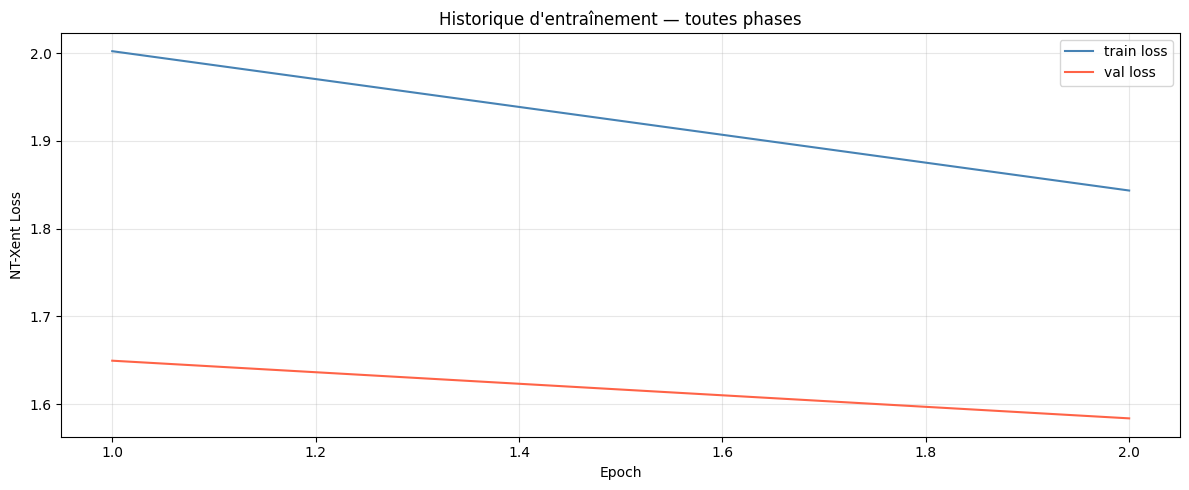

In [5]:
trainer.plot_history()

In [13]:
# Test manuel de test_step sur un batch de validation
for batch, labels in ds.val.take(1):
    z_ear, z_hrtf = model(batch, training=False)
    
    import tensorflow as tf
    from src.models import nt_xent_loss
    
    loss = nt_xent_loss(z_ear, z_hrtf, temperature=0.07)
    
    print(f'z_ear shape   : {z_ear.shape}')
    print(f'z_hrtf shape  : {z_hrtf.shape}')
    print(f'Normes z_ear  : {tf.norm(z_ear, axis=-1).numpy()}')
    print(f'Normes z_hrtf : {tf.norm(z_hrtf, axis=-1).numpy()}')
    
    sim = tf.matmul(z_ear, z_hrtf, transpose_b=True)
    print(f'\nMatrice similarité (min/max) : [{sim.numpy().min():.4f}, {sim.numpy().max():.4f}]')
    print(f'Diagonale (paires correctes) : {tf.linalg.diag_part(sim).numpy()}')
    print(f'\nNT-Xent loss : {loss.numpy():.6f}')


z_ear shape   : (8, 128)
z_hrtf shape  : (8, 128)
Normes z_ear  : [1.         1.         1.         0.99999994 1.         1.
 1.         0.99999994]
Normes z_hrtf : [0.9999999  1.         0.99999994 1.         0.99999994 0.99999994
 1.         1.        ]

Matrice similarité (min/max) : [-0.2875, 0.6519]
Diagonale (paires correctes) : [0.45287293 0.6518848  0.55792165 0.645002   0.60423124 0.12574446
 0.41677052 0.48148185]

NT-Xent loss : 0.761873


In [10]:
#tensorboard

%reload_ext tensorboard
%tensorboard --logdir checkpoints/ --port 6006

Launching TensorBoard...

In [ ]:
!mlflow ui --backend-store-uri checkqpoints/mlruns --port 5000

^C
